# Workshop 11: Markov Decision Processes (MDP)

In the previous workshop, we explored (multi-armed) bandits, and how they explore / exploit values for different actions.
What this has been lacking, is the concept of a "state" the agent is "in". Depending on the state, the agent will be presented with different value estimations for the set of possible actions.

In this workshop, we will explore how an agent interacts with an environment over time, and how it can learn how to behave in different states.

## Recap
### Markov Decision Process
First, let's recap a Markov Decision Process, the formalization of any Reinforcement Learning Environment:

A **Markov Decision Process (MDP)** is a tuple $(S, A, P, R, \gamma)$, where:
- $S$ is a finite set of states
- $A$ is a finite set of actions
- $P$ is the state transition probability function $P(s'|s,a)$
- $R$ is the reward function $R(s,a,s')$
- $\gamma$ is the discount factor $\gamma \in [0,1]$

The central idea of MDPs is that the agent's behavior is determined by the state it is in, and the action it takes, nothing else. That means the future is independent of the past given the present.
This means that the agents can control its action based on (only) its currently known state.

The goal is to find a policy $\pi(a|s)$ that maximizes the expected discounted return.
The expected return can be expressed as:
- From state $s$: $v_{\pi}(s)=\mathbb{E}_{\pi}[G_{t}|S_{t}=s]=\mathbb{E}_{\pi}[\sum_{k=0}^{\infty}\gamma^{k}R_{t+k+1}|S_{t}=s]$
- From state $s$, taking action $a$: $q_{\pi}(s,a)=\mathbb{E}_{\pi}[G_{t}|S_{t}=s,A_{t}=a]=\mathbb{E}_{\pi}[\sum_{k=0}^{\infty}\gamma^{k}R_{t+k+1}|S_{t}=s,A_{t}=a]$


The **Bellmann expectation equation** is the decomposition of the above into immediate reward plus discounted value of the successor state(s):
- From state $s$: $V_{\pi}(s)=\mathbb{E}_{\pi}[R_{t+1}+\gamma V_{\pi}(S_{t+1})|S_{t}=s] =\sum_a\pi(a|s)\sum_{s^\prime}P(s^\prime|s,a)[R(s,a,s^\prime)+\gamma V^\pi(s^\prime)]$
- From state $s$, taking action $a$: $Q_{\pi}(s,a)=\mathbb{E}_{\pi}[R_{t+1}+\gamma V_{\pi}(S_{t+1})|S_{t}=s,A_{t}=a] = R(s,a,s^\prime)+\gamma V^\pi(s^\prime)$

The **Bellmann optimality equation** is the foundation for deciding how to behave in different states:
- The value of a state under an optimal policy equals the expected return the best action from that state: $V_{*}(s)=\begin{array}{c}{max}\\{a}\end{array}\sum_{s^{\prime},r}P(s^{\prime}|s,a)\left[R(s,a,s^{\prime})+\gamma V_{*}(s^{\prime})\right]$
- The optimal action $a$ to take in state $s$ is the one that maximizes $Q^*(s,a)=\sum_{s^\prime}P(s^\prime|s,a)[R(s,a,s^\prime)+\gamma\max_{a^\prime}Q^*(s^\prime,a^\prime)]$

### Dynamic Programming
We consider an MDP *solved* if we know the optimal value function.
We start with a scenario where a model of the environment is known, and we want to learn how to behave in it. The model encapsulates transition probabilities $P$, and reward function $R$.

We can *plan* the optimal policy through **Dynamic Programming**. Specifically, we will look at an example where we do **value iteration**:

We use the Bellman optimality equations for updating the value function $V$:
1. We start with an arbitrary intial value function $V_0$. In each iteration, $k$, we calculate the next value function $V_{k+1}$ for all states $s$ by sing the values from the previous iteration $V_k$:

$V_{k+1}(s)\leftarrow\max_{a\in A}\sum_{s^\prime}P(s^\prime|s,a)[R(s,a,s^\prime)+\gamma V_k(s^\prime)]$
 
2. We repeat this process until convergence on some small threshold $\epsilon$.

$\|V_{k+1}-V_k\|_\infty< \epsilon$

3. The optimal policy can then easily be extracted by looking at which action maximizes the value function at each state.

$\pi^*(s)=\arg\max_{a\in A}\sum_{s^\prime}P(s^\prime|s,a)[R(s,a,s^\prime)+\gamma V^*(s^\prime)]$

## The `gym` framework in Python

While there are many frameworks surrounding planning and learning in decision processes (See how I did not mention Reinforcement Learning explicitly here? Well, this is because MDP and dynamic programming, which we discussed up until now are not specifically related to learning.) in Python, we will concentrate on one of the biggest and most popular ones: `gymnasium`, in the past `gym`, still mostly referred to with that short form.
> You can find its documentation here: https://gymnasium.farama.org/

It is a standardized toolkit for RL environments that makes it easy to create and reuse custom environments or simply use environments contributed by the community and similarly use RL agents (e.g., Stable Baselines3 ones: https://stable-baselines3.readthedocs.io/) to interact with them using a standardized API.

This allows us do something like this in a couple of lines:

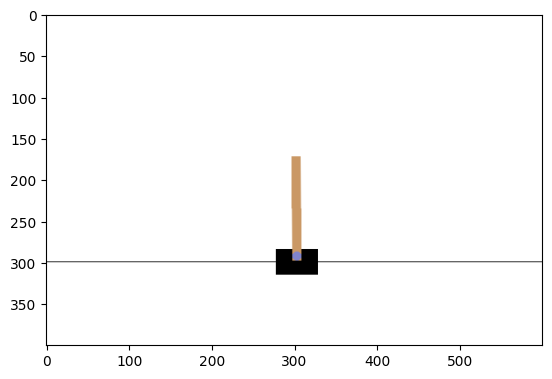

In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
from IPython import display
%matplotlib inline

from stable_baselines3 import DQN

env = gym.make("CartPole-v1", render_mode="rgb_array")

model = DQN("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10_000)

vec_env = model.get_env()
obs = vec_env.reset()
for i in range(20):
    action, _state = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)
    
    plt.imshow(vec_env.render("rgb_array"))
    display.display(plt.gcf())
    display.clear_output(wait=True)

You can forget about most of what happened above and just focus on the fact that we were able to use an agent to interact with a specified environment and visualize it in a couple of lines of code.
- We use `env = gym.make("CartPole-v1")` to create the environment. Here is a gallery of implemented control environments: https://gymnasium.farama.org/environments/classic_control/
- In the beginning, always remember to reset the environment to generate a first observation: `state, info = env.reset()`
- Then, we can interact with the environment by taking actions: `state, reward, terminated, truncated, info = env.step(action)`

If we only want to generate experiences (exploration), we can simply sample a random action from the provided action set: `action = env.action_space.sample()`
We can peek into the observation and the action space to get a feeling for the problem:

In [2]:
env.action_space

Discrete(2)

This tells us that there are two possible, discrete options. `gym` will represent them as integers 0 and 1.

In [3]:
[env.action_space.sample() for _ in range(5)]

[np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]

In [4]:
env.observation_space

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

This tells us a little bit more:
- The observation space is a special predefined one: A "box" that defined bounds for each dimension: https://gymnasium.farama.org/api/spaces/fundamental/#gymnasium.spaces.Box
- There are four dimensions, which correspond to the four dimensions that we can look up in the environment: https://gymnasium.farama.org/environments/classic_control/cart_pole/#observation-space
- The bounds are (-4.8, 4.8) for the cart position, (-inf, inf) for the cart velocity, (-24°, 24°) for the pole angle (converted to radians), and (-inf, inf) for the pole angular velocity.

As you can see, we use matplotlib together with special `render` function calls to visualize. This is a nice workaround in notebook environments, because we cannot be sure that Python can spawn a GUI.
Usually, if you run this locally on your computer, you can simply create the environment using the parameter `render_mode="human"` and it will automatically render the environment in a separate window.
You don't even need to call `render` explicitly, as `gym` will do that automatically in this render mode at every `step()`.

## Model-Based: Dynamic Programming in `gym`
Let's implement a planning problem and solve it using dynamic programming in `gym`!
We will use `gym` to load a pre-defined environment and for this special case of DP, we will use the provided transition model that comes with the environment (not all environments have this!)

The environment is described here: https://gymnasium.farama.org/environments/toy_text/frozen_lake/
The goal for the player is to reach the goal on the opposite corner of where they start. There are holes in the frozen lake and if they fall in one, the episode is over. If they reach the goal without falling in a hole, they get a positive reward, otherwise there is no reward.

<img src="./images/frozen_lake.gif" style="width: 300px;"/>

### Deterministic Environment
We start with a deterministic version of the environment, where it is not slippery, meaning that every action will lead to the desired outcome with 100% probability.

In [5]:
import gymnasium as gym
import torch
import matplotlib.pyplot as plt

# Make sure to have matplotlib render plots inline
%matplotlib inline

# Create the FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array', map_name="4x4")

# Get the number of states and actions
num_states = env.observation_space.n
num_actions = env.action_space.n

print(f"Number of states: {num_states}")
print(f"Number of actions: {num_actions}")

# The actions are: 0: LEFT, 1: DOWN, 2: RIGHT, 3: UP

Number of states: 16
Number of actions: 4


Let's have a look at this particular instantiation of the frozen lake! (If we don't provide a map, it will generate a random one, with size 4x4)

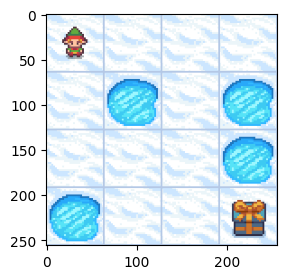

In [6]:
env.reset()
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(env.render())
plt.show()

For Value Iteration (the DP algorithm), we need a complete model of the environment. This means we need to know the transition probabilities and the reward function. We can use the `env.unwrapped.P` attribute for this that `gym` provides:
- The keys are the states (0 to 15)
- The values are dictionaries where the keys are the actions (0 to 3) and the values are tuples of (probability, next_state, reward, terminal)

As you can see, the propability is always 1.0, because the environment is deterministic.

In [7]:
# Access the transition matrix using env.unwrapped.P
P = env.unwrapped.P

# Let's look at the transitions for state 1, action 2 (RIGHT)
state = 1
action = 2

# The output now shows a single, certain outcome
print(f"Dynamics for state {state} and action {action}:")
print(P[state][action])

Dynamics for state 1 and action 2:
[(1.0, 2, 0, False)]


Let's implement Value Iteration!

In [8]:
import numpy as np

# --- Hyperparameters ---
gamma = 0.99      # Discount factor
theta = 1e-8      # Convergence threshold
max_iterations = 100

# --- Algorithm ---
# 1. Initialize the value function
V = np.zeros(num_states)

for i in range(max_iterations):
    delta = 0
    
    # 2. Loop through each state
    for s in range(num_states):
        v_old = V[s]
    
        # 3. For each action, compute its expected value
        action_values = np.zeros(num_actions)
        for a in range(num_actions):
            expected_value = 0
            for prob, next_state, reward, done in P[s][a]:
                expected_value += prob * (reward + gamma * V[next_state])
            action_values[a] = expected_value
            
        # 4. Update the value function for state s with the max action value
        V[s] = np.max(action_values)
        
        # 5. Update delta
        delta = max(delta, abs(v_old - V[s]))

    # Print the current iteration and delta
    print(f"Iteration {i+1}: Values = {V.tolist()}")
        
    # 6. Check for convergence
    if delta < theta:
        print(f"Value Iteration converged at iteration {i+1}")
        break

Iteration 1: Values = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
Iteration 2: Values = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Iteration 3: Values = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9801, 0.0, 0.0, 0.9801, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Iteration 4: Values = [0.0, 0.0, 0.9702989999999999, 0.96059601, 0.0, 0.0, 0.9801, 0.0, 0.9702989999999999, 0.9801, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Iteration 5: Values = [0.0, 0.96059601, 0.9702989999999999, 0.96059601, 0.96059601, 0.0, 0.9801, 0.0, 0.9702989999999999, 0.9801, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Iteration 6: Values = [0.9509900498999999, 0.96059601, 0.9702989999999999, 0.96059601, 0.96059601, 0.0, 0.9801, 0.0, 0.9702989999999999, 0.9801, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Iteration 7: Values = [0.9509900498999999, 0.96059601, 0.9702989999999999, 0.96059601, 0.96059601, 0.0, 0.9801, 0.0, 0.9702989999999999, 0.9801, 0.99, 0.0, 0.0, 0.99, 1.0, 0.0]
Value Iteration c

We can see how the value iteration works "backwards" from the known goal state where the value is known to be the reward (1).

![Backup Diagram DP](./images/backup_diagram_DP.png)

Given the optimal values, we can directly extract the optimal policy (remember: $\pi^*(s)=\arg\max_{a\in A}\sum_{s^\prime}P(s^\prime|s,a)[R(s,a,s^\prime)+\gamma V^*(s^\prime)]$ )

In [9]:
# Initialize the policy table
policy = np.zeros(num_states, dtype=int)

# Loop through each state to find the best action
for s in range(num_states):
    action_values = np.zeros(num_actions)
    # Compute the value of each action
    for a in range(num_actions):
        expected_value = 0
        for prob, next_state, reward, done in P[s][a]:
            expected_value += prob * (reward + gamma * V[next_state])
        action_values[a] = expected_value
        
    # Choose the action with the highest value
    policy[s] = np.argmax(action_values)

In [10]:
policy

array([1, 2, 1, 0, 1, 0, 1, 0, 2, 1, 1, 0, 0, 2, 2, 0])

In [11]:
print("--- Optimal Value Function ---")
# Reshape V to the 4x4 grid for easier interpretation
print(V.reshape(4, 4))

print("\n--- Optimal Policy ---")
action_map = {0: "<", 1: "v", 2: ">", 3: "^"}
policy_grid = [action_map[action] for action in policy]
policy_grid[-1] = 'G'

policy_array = np.array(policy_grid).reshape(4, 4)
# Display the policy grid
for row in policy_array:
    print(" ".join(row))

--- Optimal Value Function ---
[[0.95099005 0.96059601 0.970299   0.96059601]
 [0.96059601 0.         0.9801     0.        ]
 [0.970299   0.9801     0.99       0.        ]
 [0.         0.99       1.         0.        ]]

--- Optimal Policy ---
v > v <
v < v <
> v v <
< > > G


Let's watch the agent in action!

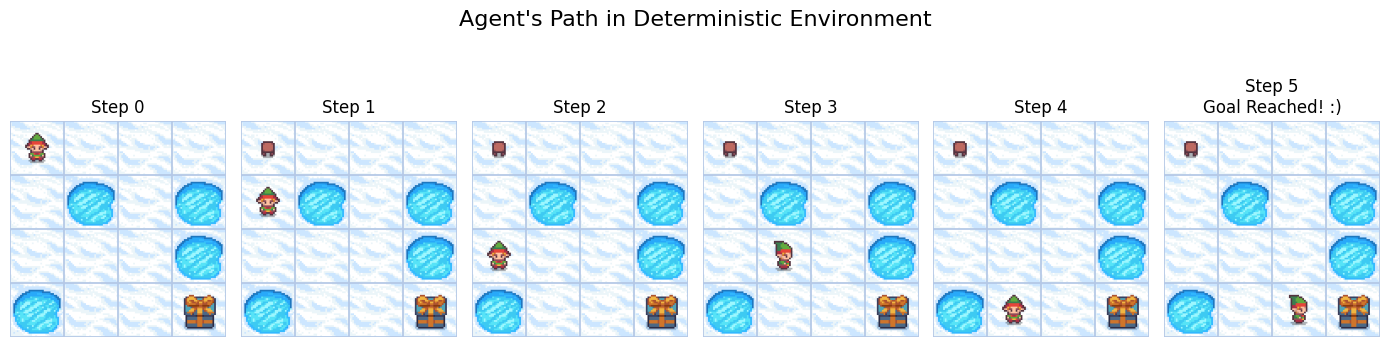

In [14]:
# Setup the subplot. figsize is adjusted for a horizontal layout.
fig, axes = plt.subplots(1, 6, figsize=(14, 4)) # we will just exploit the fact that we know that the agent needs five steps ;)
fig.suptitle("Agent's Path in Deterministic Environment", fontsize=16)

# Reset the environment to get the initial state
state, info = env.reset()
done = False
reward = 0

# Loop for a maximum of 6 steps
for i in range(6):
    # Render the current state and display it on the i-th subplot
    frame = env.render()
    axes[i].imshow(frame)
    axes[i].axis('off') # Hide axis ticks and labels

    # If the episode is not finished, take the next step
    if not done:
        # Get the best action from our optimal policy
        action = policy[state]
        # Execute the action
        state, reward, terminated, truncated, info = env.step(action)
        # Check if the episode has ended
        done = terminated or truncated
        axes[i].set_title(f"Step {i}")
    
    # If the episode is finished, update the title and stop
    if done:
        # Set a final title on the last frame
        result_text = "Goal Reached! :)" if reward == 1.0 else "Fell in Hole! :/"
        axes[i].set_title(f"Step {i}\n{result_text}")
        # Hide any remaining (unused) subplots
        for j in range(i + 1, 6):
            axes[j].axis('off')
        break

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# It's good practice to close the environment
env.close()

### Stochastic Environment
Let's make the lake slippery!

In [15]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Re-create the environment with is_slippery=True
stochastic_env = gym.make("FrozenLake-v1", is_slippery=True, render_mode='rgb_array', map_name="4x4")

# The model P is now more complex
P_stochastic = stochastic_env.unwrapped.P

This is the same pre-loaded lake!

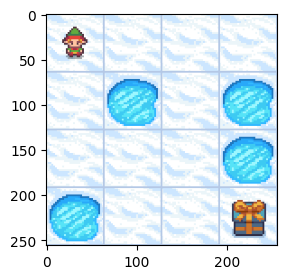

In [16]:
env.reset()
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(env.render())
plt.show()

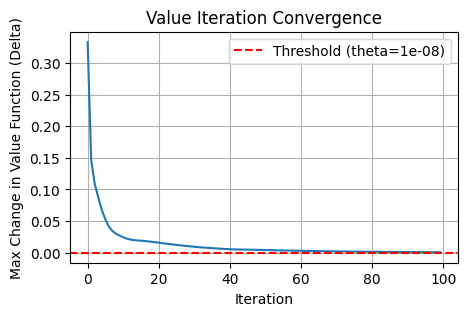

In [17]:
# --- Hyperparameters ---
gamma = 0.99
theta = 1e-8
max_iterations = 100

# --- Algorithm ---
V_stochastic = np.zeros(stochastic_env.observation_space.n)
# To store the delta at each iteration
deltas = []

for i in range(max_iterations):
    delta = 0
    for s in range(stochastic_env.observation_space.n):
        v_old = V_stochastic[s]
        action_values = np.zeros(stochastic_env.action_space.n)
        for a in range(stochastic_env.action_space.n):
            expected_value = 0
            # The P matrix now has multiple outcomes per action
            for prob, next_state, reward, done in P_stochastic[s][a]:
                expected_value += prob * (reward + gamma * V_stochastic[next_state])
            action_values[a] = expected_value
        
        V_stochastic[s] = np.max(action_values)
        delta = max(delta, abs(v_old - V_stochastic[s]))
    
    deltas.append(delta) # Record the change for this iteration
    
    if delta < theta:
        print(f"Value Iteration converged at iteration {i+1}")
        break

# --- Plotting Convergence ---
plt.figure(figsize=(5, 3))
plt.plot(deltas)
plt.title("Value Iteration Convergence")
plt.xlabel("Iteration")
plt.ylabel("Max Change in Value Function (Delta)")
plt.axhline(y=theta, color='r', linestyle='--', label=f'Threshold (theta={theta})')
plt.legend()
plt.grid(True)
plt.show()

That took many more iterations to converge! Keep in mind that this is still the same, super simple 4x4 map, just this time with slippery ice (probability of actions leading to the intended outcome being 1/3. With 1/3 probability the agent will move in either direction perpendicular to the indented direction).

In [18]:
# Extract the optimal policy for the stochastic environment
policy_stochastic = np.zeros(stochastic_env.observation_space.n, dtype=int)

for s in range(stochastic_env.observation_space.n):
    action_values = np.zeros(stochastic_env.action_space.n)
    for a in range(stochastic_env.action_space.n):
        expected_value = 0
        for prob, next_state, reward, done in P_stochastic[s][a]:
            expected_value += prob * (reward + gamma * V_stochastic[next_state])
        action_values[a] = expected_value
    policy_stochastic[s] = np.argmax(action_values)

print("--- Optimal Value Function ---")
# Reshape V to the 4x4 grid for easier interpretation
print(V.reshape(4, 4))

# --- Print the policy ---
print("--- Optimal Policy (Stochastic) ---")
action_map = {0: "<", 1: "v", 2: ">", 3: "^"}
policy_grid = [action_map[action] for action in policy_stochastic]
policy_grid[-1] = 'G'
policy_array = np.array(policy_grid).reshape(4, 4)
for row in policy_array:
    print(" ".join(row))

--- Optimal Value Function ---
[[0.95099005 0.96059601 0.970299   0.96059601]
 [0.96059601 0.         0.9801     0.        ]
 [0.970299   0.9801     0.99       0.        ]
 [0.         0.99       1.         0.        ]]
--- Optimal Policy (Stochastic) ---
< ^ ^ ^
< < < <
^ v < <
< > v G


**Question:** Do you realize something when looking at the policy and the lake environment?

**Answer:** The plan "exploits" the fact that the ice is only slippery in perpendicular direction, meaning it will move left at the left edge to not fall into the hole, but rather move down or up - while this might not be greedy (go down), it is the best plan considering the knowledge of the values.

Again, let's look at the agent in action. This time, we can't be sure how many steps the agent will take to terminate (fall in a hole or reach the goal). We will let the agent finish one episode, collect all the frames, and render a video:

In [19]:
# First, run an episode and collect all the frames
frames = []
state, info = stochastic_env.reset()
done = False
max_steps = 50 # Set a max step limit for time

for _ in range(max_steps):
    frames.append(stochastic_env.render())
    if done:
        break
    action = policy_stochastic[state]
    state, reward, terminated, truncated, info = stochastic_env.step(action)
    done = terminated or truncated

stochastic_env.close()

# Now, create the animation
fig = plt.figure(figsize=(4, 4))
plt.axis('off')
patch = plt.imshow(frames[0])

def animate(i):
    patch.set_data(frames[i])
    return patch,

anim = FuncAnimation(fig, animate, frames=len(frames), interval=250, blit=True)
plt.close(fig)

# Display the animation in the notebook, should work in VS Code and most modern browsers
HTML(anim.to_html5_video())

## Model-Free: Monte Carlo in `gym`

So far, we assumed the perfect world where we know $P$ and $R$. But what if we don't? In that case, we need to use **model-free** learning. The agent has no prior knowledge of the environment's dynamics. It has to learn them by interacting with the environment. Interaction with the environment means taking actions and observing the outcome (next state and reward). This is the far more common scenario in the real world and what Reinforcement Learning is all about.

**Monte Carlo** (MC) is a model-free method that simulates full experiences (complete episodes). An episode is a full sequence of steps from a start state to a terminal state, it describes a full lifecycle of the agent in the environment.

In Dynamic Programming, we could learn the state-value function $V(s)$ and still find the optimal policy because we had the model $P$ to perform a one-step lookanead ("what if we take that action?").

$$\pi^*(s)=\arg\max_a\sum_{s'}P(s'|s,a)[R(s,a,s')+\gamma V^*(s')]$$

Without the model $P$, $V(s)$ is no longer enough! We can't predict the outcome of actions. Therefore, we must learn the action-value function, $Q(s,a)$, directly. $Q(s,a)$ tells us the expected return of taking action a from state s and then following our policy thereafter.

MC estimates action values $Q(s,a)$ by averaging over the returns (cumulative rewards, discounted) it has observed after taking action $a$ in state $s$. This means we need a lot of experiences to ensure a pair $(s,a)$ is well represented. The return is the foundation of MC, denoted as $G_{t}$. The return is the total discounted reward from a time step $t$ until the end of the episode.
$$G_{t} = R_{t+1} + \gamma R_{t+2} + \gamma^{2} R_{t+3} + \cdots + \gamma^{T-t-1} R_{T}$$ 
Where $T$ is the final time step. To calculate this, we work backwards from the end of an episode.

![Backup Diagram MC](./images/backup_diagram_MC.png)

To find the optimal policy, we will use **Monte Carlo Control**.

We will consider a tabular setting where we have a Q-table $Q(s,a)$ for each state-action pair. We can initialize it to zero.

1. Run a full episode using a policy $\pi$ to collect experience.
2. After the episode, update the Q-table based on the observed return. We can use a simple update rule like $Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha (G_t - Q(s_t,a_t))$ where $G_t$ is the total discounted return at time $t$.

The only question remaining is how to behave in the environment ("What is $\pi$?"). To ensure we explore the environment, we won't always pick the best-known (return-maximizing) action. Rather, we will use what we already know from multi-armed bandits: An **$\epsilon$-greedy** policy:
- With probability $1-\epsilon$, we will pick the best-known action (highest $Q$ value, *"exploitation"*).
- With probability $\epsilon$, we will pick a random action (*"exploration"*).

Again, we will use the **FrozenLake-v1** environment, but this time, we will not exploit knowledge of `env.unwrapped.P`, meaning the environment is opaque to our agent. Our agent needs to learn a good policy purely by *trial-and-error*!

We implement a *first-visit* MC control algorithm, which is a variant that only consider average returns the first time a state is visited in an episode. This differs from *every-visit* Monte Carlo, which averages returns over all visits to a state. The advantage is that it is more efficient, since we only need to store the frist return for each state. However, the disadvantage is that it can be less accurate, since it may not capture the full distribution of returns for a state.

In [20]:
from collections import defaultdict

# Setup the environment
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
num_states = env.observation_space.n
num_actions = env.action_space.n

# --- Hyperparameters ---
num_episodes = 20000        # Number of episodes to run for training
learning_rate = 0.05        # Alpha
gamma = 0.99                # Discount factor

# Exploration-exploitation trade-off
epsilon = 0.35              # Exploration rate (35%)

In [21]:
# Initialize the Q-table using a defaultdict
# This allows us to create entries for states as we see them
Q = defaultdict(lambda: np.zeros(num_actions))

# To track rewards for plotting
episode_rewards_history = []

print("Training started...")
# --- Main Training Loop ---
for episode in range(num_episodes):
    # 1. Generate an episode
    episode_trajectory = []
    state, info = env.reset()
    done = False
    
    while not done:
        # Choose action using epsilon-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(Q[state]) # Exploit
            
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        episode_trajectory.append((state, action, reward))
        state = next_state

    # Record the total reward for this episode (for the final plot)
    # The total reward is simply the last reward in this specific environment
    episode_rewards_history.append(episode_trajectory[-1][2])

    # 2. Update Q-values using the generated episode (First-Visit MC)
    visited_state_actions = set()
    returns = 0.0
    
    # Work backwards from the end of the episode
    for state, action, reward in reversed(episode_trajectory):
        # Calculate the return for this step
        returns = reward + gamma * returns
        
        # If this is the first time we've seen this state-action pair in this episode
        if (state, action) not in visited_state_actions:
            # Apply the incremental update rule
            Q[state][action] = Q[state][action] + learning_rate * (returns - Q[state][action])
            visited_state_actions.add((state, action))

print("Training finished.")

Training started...
Training finished.


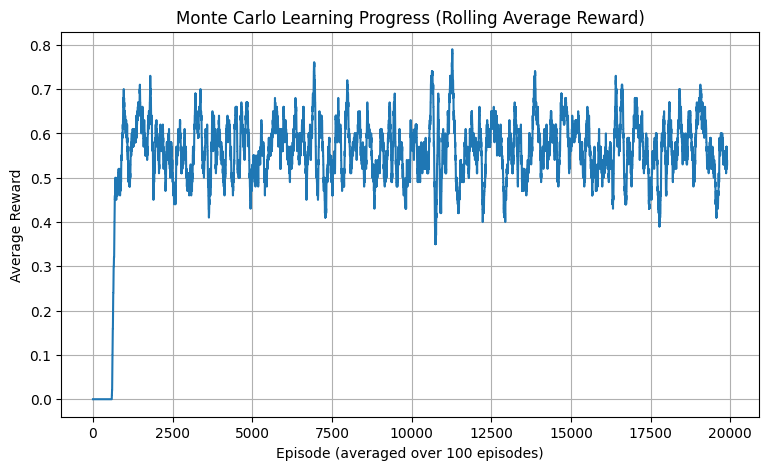

In [22]:
# Calculate the rolling average of rewards (plotting single rewards at 0 or 1 doesn't make sense)
window_size = 100
rolling_avg_rewards = np.convolve(episode_rewards_history, np.ones(window_size)/window_size, mode='valid')

# Plot the learning progress
plt.figure(figsize=(9, 5))
plt.plot(rolling_avg_rewards)
plt.title("Monte Carlo Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

Let's extract the policy from the Q-table and see how it looks like.

In [23]:
policy_mc = np.array([np.argmax(Q[s]) if s in Q else 0 for s in range(num_states)])

print("--- Policy Learned by Monte Carlo Agent ---")

# Define the mapping from action numbers to arrows
action_map = {0: "<", 1: "v", 2: ">", 3: "^"}

# Create the policy grid with arrows
policy_grid = [action_map[action] for action in policy_mc]

# Overlay the holes (H) and goal (G) for context
# env.desc gives the layout of the environment
flat_desc = env.unwrapped.desc.flatten()
for i, char_bytes in enumerate(flat_desc):
    char = char_bytes.decode('utf-8')
    if char in 'HG':
        policy_grid[i] = char

# Reshape to a 4x4 grid and print
policy_array = np.array(policy_grid).reshape(4, 4)
for row in policy_array:
    # Join with spaces for better readability
    print("  ".join(row))

--- Policy Learned by Monte Carlo Agent ---
v  <  ^  <
v  H  v  H
>  >  v  H
H  >  >  G


In [24]:
# we can reuse the animation code from above
frames = []
state, info = env.reset()
done = False
for _ in range(50):
    frames.append(env.render())
    if done: break
    action = policy_mc[state]
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
env.close()

# Create and display the animation
fig_mc = plt.figure(figsize=(4, 4))
plt.axis('off')
patch_mc = plt.imshow(frames[0])
def animate_mc(i):
    patch_mc.set_data(frames[i])
    return patch_mc,

anim_mc = FuncAnimation(fig_mc, animate_mc, frames=len(frames), interval=200, blit=True)
plt.close(fig_mc)
HTML(anim_mc.to_html5_video())

That worked out pretty well, even without a model of the environment!

Let's try out something more complex:

In [25]:
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

# Setup the environment
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array", desc=generate_random_map(size=8))
num_states = env.observation_space.n
num_actions = env.action_space.n

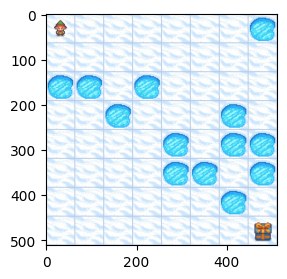

In [26]:
env.reset()
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(env.render())
plt.show()

Oops, that looks a lot more complex!

### Exercise 

Given a stochastic, and larger world (e.g. 8x8), can you find a good policy for it?

1. First, try to conquer the task just by tweaking the hyperparameters below (learning rate, discount factor, etc.)!
1. If that fails, think back to the bandit workshop and see if you can adapt any of the techniques for exploration vs. exploitation here!

In [27]:
# --- Hyperparameters ---
num_episodes = 20000        # Number of episodes to run for training
learning_rate = 0.05        # Alpha
gamma = 0.99                # Discount factor

# Exploration-exploitation trade-off
epsilon = 0.35               # Exploration rate (35%)

Training started...
Training finished.


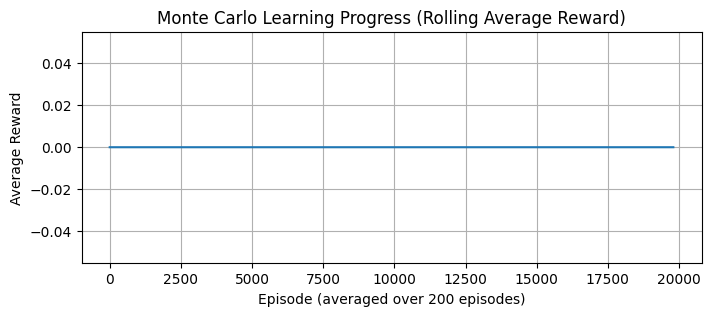

In [28]:

Q = defaultdict(lambda: np.zeros(num_actions))

episode_rewards_history = []

print("Training started...")
for episode in range(num_episodes):
    episode_trajectory = []
    state, info = env.reset()
    done = False
    
    while not done:

        if np.random.random() < epsilon:
            action = env.action_space.sample() 
        else:
            action = np.argmax(Q[state]) 
            
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        episode_trajectory.append((state, action, reward))
        state = next_state

    episode_rewards_history.append(episode_trajectory[-1][2])

    visited_state_actions = set()
    returns = 0.0
    
    for state, action, reward in reversed(episode_trajectory):
        returns = reward + gamma * returns
        
        if (state, action) not in visited_state_actions:
            Q[state][action] = Q[state][action] + learning_rate * (returns - Q[state][action])
            visited_state_actions.add((state, action))

print("Training finished.")

# plot learning progress
window_size = 200
rolling_avg_rewards = np.convolve(episode_rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(8, 3))
plt.plot(rolling_avg_rewards)
plt.title("Monte Carlo Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# extract policy
policy_mc = np.array([np.argmax(Q[s]) if s in Q else 0 for s in range(num_states)])

# animation
frames = []
state, info = env.reset()
done = False
for _ in range(100):
    frames.append(env.render())
    if done: break
    action = policy_mc[state]
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
env.close()

fig_mc = plt.figure(figsize=(4, 4))
plt.axis('off')
patch_mc = plt.imshow(frames[0])
def animate_mc(i):
    patch_mc.set_data(frames[i])
    return patch_mc,

anim_mc = FuncAnimation(fig_mc, animate_mc, frames=len(frames), interval=200, blit=True)
plt.close(fig_mc)
HTML(anim_mc.to_html5_video())